# RFM + Clustering + Churn

Este notebook simula um projeto completo de análise de clientes:

**Dados transacionais → tabela de clientes → RFM + outras features → clustering → segmentação → modelo de churn → probabilidade → priorização → ação de retenção**

O objetivo é mostrar como combinar aprendizado **não supervisionado** (segmentação) com aprendizado **supervisionado** (previsão de churn).

> Os dados são sintéticos para fins didáticos. Em um projeto real, a primeira etapa seria construir a tabela analítica usando SQL.

## 1. Visão do projeto

1. Gerar/ler dados transacionais
2. Construir uma tabela de clientes
3. Calcular RFM
4. Criar outras variáveis comportamentais
5. Fazer EDA
6. Aplicar K-Means para segmentação
7. Interpretar os clusters
8. Definir churn futuro
9. Treinar modelo supervisionado
10. Comparar modelo com e sem cluster
11. Gerar `P(churn)`
12. Priorizar clientes considerando risco e valor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

np.random.seed(42)

pd.set_option("display.max_columns", 50)

## 2. Dados transacionais

Em um projeto real, esta tabela poderia vir de SQL.

Exemplo conceitual:

```sql
SELECT
    customer_id,
    purchase_date,
    amount,
    product_category,
    channel
FROM transactions;
```

Aqui vamos gerar uma base sintética.

In [2]:
# Gerando clientes
n_customers = 2500
customer_ids = np.arange(1, n_customers + 1)

# Perfil latente usado apenas para gerar dados sintéticos
segment = np.random.choice(
    ["high_value", "regular", "low_value", "at_risk"],
    size=n_customers,
    p=[0.15, 0.45, 0.30, 0.10]
)

rows = []

categories = ["Skin Care", "Filler", "Biostimulator", "Toxin"]

for cid, seg in zip(customer_ids, segment):
    if seg == "high_value":
        n_orders = np.random.poisson(18) + 2
        avg_amount = 900
        recency_max = 45
    elif seg == "regular":
        n_orders = np.random.poisson(8) + 1
        avg_amount = 500
        recency_max = 90
    elif seg == "low_value":
        n_orders = np.random.poisson(3) + 1
        avg_amount = 220
        recency_max = 180
    else:
        n_orders = np.random.poisson(5) + 1
        avg_amount = 400
        recency_max = 300

    # Compras relativamente recentes ou antigas, dependendo do perfil
    days_ago = np.random.randint(1, recency_max + 1, size=n_orders)

    for d in days_ago:
        amount = max(30, np.random.normal(avg_amount, avg_amount * 0.25))
        rows.append({
            "customer_id": cid,
            "purchase_date": pd.Timestamp("2026-08-31") - pd.Timedelta(days=int(d)),
            "amount": amount,
            "product_category": np.random.choice(categories),
            "channel": np.random.choice(["Online", "Sales Rep", "Distributor"])
        })

transactions = pd.DataFrame(rows)

transactions.head(), transactions.shape

(   customer_id purchase_date      amount product_category      channel
 0            1    2026-07-24  618.995045           Filler    Sales Rep
 1            1    2026-06-25  637.644470        Skin Care    Sales Rep
 2            1    2026-07-03  651.783706           Filler       Online
 3            1    2026-06-23  391.500000           Filler  Distributor
 4            1    2026-08-18  651.158264    Biostimulator       Online,
 (22433, 5))

## 3. Tabela de clientes

A partir das transações, transformamos várias linhas por cliente em uma linha por cliente.

Esta é a **tabela analítica** que será usada nas etapas seguintes.

In [3]:
reference_date = pd.Timestamp("2026-08-31")

customer = (
    transactions.groupby("customer_id")
    .agg(
        last_purchase=("purchase_date", "max"),
        frequency=("purchase_date", "count"),
        monetary=("amount", "sum"),
        avg_ticket=("amount", "mean"),
        first_purchase=("purchase_date", "min")
    )
    .reset_index()
)

customer["recency"] = (
    reference_date - customer["last_purchase"]
).dt.days

customer["tenure_days"] = (
    reference_date - customer["first_purchase"]
).dt.days

customer["avg_days_between_orders"] = (
    customer["tenure_days"] / customer["frequency"].clip(lower=2)
)

customer.head()

,customer_id,last_purchase,frequency,monetary,avg_ticket,first_purchase,recency,tenure_days,avg_days_between_orders
0,1,2026-08-18,11,6040.353034,549.123003,2026-06-06,13,86,7.818182
1,2,2026-06-09,2,878.580579,439.290290,2026-04-30,83,123,61.500000
2,3,2026-08-18,2,443.070681,221.535340,2026-05-12,13,111,55.500000
3,4,2026-08-12,7,3523.484810,503.354973,2026-06-06,19,86,12.285714
4,5,2026-08-23,9,5012.836686,556.981854,2026-06-04,8,88,9.777778


## 4. RFM

Agora temos:

- **Recency:** dias desde a última compra
- **Frequency:** número de compras
- **Monetary:** valor total comprado

Essas três variáveis formam o RFM.

In [4]:
rfm = customer[[
    "customer_id", "recency", "frequency", "monetary"
]].copy()

rfm.describe()

,customer_id,recency,frequency,monetary
count,2500.00000,2500.000000,2500.000000,2500.000000
mean,1250.50000,21.955600,8.973200,5371.838204
std,721.83216,29.774127,6.000974,6096.434651
min,1.00000,1.000000,1.000000,112.769379
25%,625.75000,3.000000,5.000000,1206.116785
50%,1250.50000,10.000000,7.000000,3385.421962
75%,1875.25000,27.000000,11.000000,5618.708172
max,2500.00000,225.000000,30.000000,28451.798375


## 5. EDA

Antes de modelar, investigamos distribuição, valores extremos e relações entre as variáveis.

Em dados reais, esta etapa também incluiria:

- valores ausentes
- duplicidades
- inconsistências
- outliers
- regras de negócio
- distribuição temporal
- estabilidade dos dados

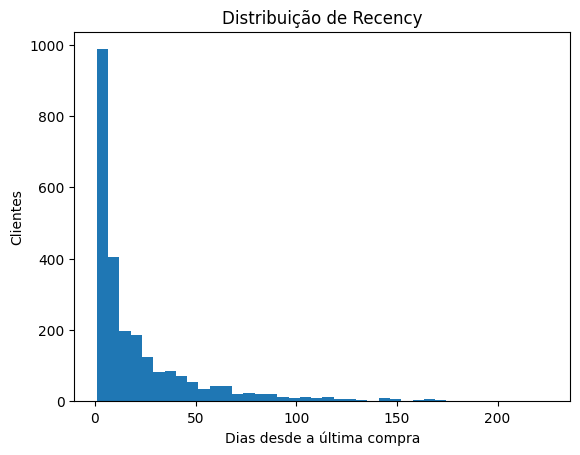

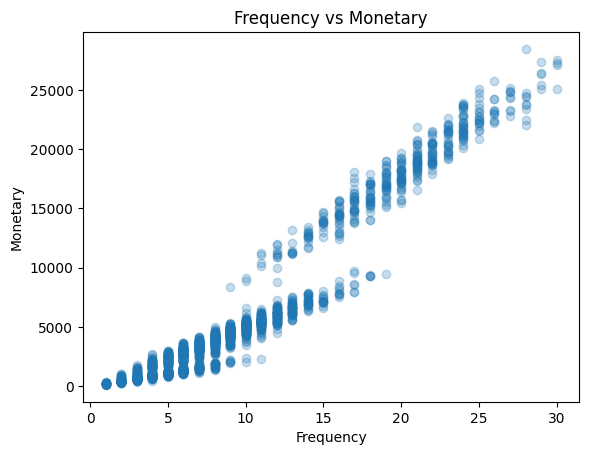

In [5]:
fig, ax = plt.subplots()
ax.hist(customer["recency"], bins=40)
ax.set_title("Distribuição de Recency")
ax.set_xlabel("Dias desde a última compra")
ax.set_ylabel("Clientes")
plt.show()

fig, ax = plt.subplots()
ax.scatter(customer["frequency"], customer["monetary"], alpha=0.25)
ax.set_title("Frequency vs Monetary")
ax.set_xlabel("Frequency")
ax.set_ylabel("Monetary")
plt.show()

## 6. Clustering

O K-Means é **não supervisionado**: não usamos churn para criar os grupos.

Usaremos RFM + algumas features comportamentais.

Como as escalas são diferentes, primeiro padronizamos as variáveis.

In [6]:
cluster_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_ticket",
    "tenure_days"
]

X_cluster = customer[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

customer["cluster"] = kmeans.fit_predict(X_cluster_scaled)

customer.groupby("cluster")[cluster_features].mean().round(2)

,recency,frequency,monetary,avg_ticket,tenure_days
cluster,,,,,
0,2.72,20.32,18312.55,902.12,43.37
1,26.98,4.86,1308.32,257.35,166.90
2,10.33,8.85,4435.27,496.54,79.57
3,101.30,3.54,1081.89,283.72,188.83


## 7. Interpretando os clusters

Os números `0, 1, 2, 3` não significam nada por si só.

Precisamos olhar para as médias e dar uma interpretação de negócio.

Uma forma simples é criar um resumo ordenado por Recency, Frequency e Monetary.

In [7]:
cluster_summary = (
    customer.groupby("cluster")[cluster_features]
    .agg(["mean", "median"])
    .round(2)
)

cluster_summary

recency        frequency         monetary           avg_ticket  \
           mean median      mean median      mean    median       mean   
cluster                                                                  
0          2.72    2.0     20.32   20.0  18312.55  18283.91     902.12   
1         26.98   25.0      4.86    5.0   1308.32   1056.69     257.35   
2         10.33    8.0      8.85    9.0   4435.27   4403.73     496.54   
3        101.30   90.5      3.54    3.0   1081.89    786.33     283.72   

                tenure_days         
         median        mean median  
cluster                             
0        899.17       43.37   44.0  
1        230.08      166.90  159.0  
2        500.77       79.57   83.0  
3        241.70      188.83  171.0

In [8]:
# Perfil simplificado de cada cluster
profile = (
    customer.groupby("cluster")
    .agg(
        customers=("customer_id", "count"),
        recency=("recency", "mean"),
        frequency=("frequency", "mean"),
        monetary=("monetary", "mean"),
        avg_ticket=("avg_ticket", "mean"),
        tenure_days=("tenure_days", "mean")
    )
    .round(2)
)

profile

,customers,recency,frequency,monetary,avg_ticket,tenure_days
cluster,,,,,,
0,395,2.72,20.32,18312.55,902.12,43.37
1,779,26.98,4.86,1308.32,257.35,166.90
2,1116,10.33,8.85,4435.27,496.54,79.57
3,210,101.30,3.54,1081.89,283.72,188.83


## 8. Criando o target de churn

Agora começa o problema **supervisionado**.

Vamos definir churn de forma temporal:

> Um cliente é considerado churn = 1 se não fizer uma nova compra nos 90 dias seguintes à data de referência.

Para um projeto real, essa definição precisa ser alinhada ao ciclo de negócio.

Aqui usamos uma simulação didática.

In [9]:
# Simulação didática do churn futuro.
# Em um projeto real, isso seria calculado observando transações após a data de corte.

# Probabilidade sintética de churn baseada no comportamento atual.
# Isso cria um target plausível para demonstrar o pipeline.
risk_score = (
    0.025 * customer["recency"]
    - 0.08 * customer["frequency"]
    - 0.00035 * customer["monetary"]
)

prob_churn = 1 / (1 + np.exp(-(risk_score - risk_score.median()) / risk_score.std()))

customer["churn"] = (
    np.random.binomial(1, prob_churn.clip(0.03, 0.90))
)

customer["churn"].mean()

0.4604

## 9. Preparando as features

Agora temos duas possibilidades:

### Modelo A — sem cluster

Usamos apenas as características do cliente.

### Modelo B — com cluster

Usamos as mesmas características + o segmento encontrado pelo K-Means.

Isso permite testar empiricamente se a segmentação adiciona informação para a previsão de churn.

In [10]:
features_base = [
    "recency",
    "frequency",
    "monetary",
    "avg_ticket",
    "tenure_days"
]

features_cluster = features_base + ["cluster"]

target = "churn"

train_df, test_df = train_test_split(
    customer,
    test_size=0.25,
    random_state=42,
    stratify=customer[target]
)

X_train_base = train_df[features_base]
X_test_base = test_df[features_base]

X_train_cluster = train_df[features_cluster]
X_test_cluster = test_df[features_cluster]

y_train = train_df[target]
y_test = test_df[target]

## 10. Modelo supervisionado sem cluster

Primeiro criamos um baseline.

A pergunta é:

> Quanto conseguimos prever churn apenas com as variáveis comportamentais?

In [11]:
model_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

model_base.fit(X_train_base, y_train)

proba_base = model_base.predict_proba(X_test_base)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, proba_base), 3))
print("PR-AUC:", round(average_precision_score(y_test, proba_base), 3))

ROC-AUC: 0.692
PR-AUC: 0.648


## 11. Modelo supervisionado com cluster

Agora adicionamos o cluster como variável categórica.

O modelo passa a receber:

```text
RFM + outras features + cluster
```

O cluster é uma representação do perfil comportamental descoberto na etapa não supervisionada.

In [12]:
numeric_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_ticket",
    "tenure_days"
]

categorical_features = ["cluster"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

model_with_cluster = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

model_with_cluster.fit(
    train_df[features_cluster],
    y_train
)

proba_cluster = model_with_cluster.predict_proba(
    test_df[features_cluster]
)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, proba_cluster), 3))
print("PR-AUC:", round(average_precision_score(y_test, proba_cluster), 3))

ROC-AUC: 0.692
PR-AUC: 0.648


## 12. Comparação

O ponto não é assumir que o cluster melhora o modelo.

Nós testamos:

```text
Modelo A:
RFM + outras features

vs.

Modelo B:
RFM + outras features + cluster
```

Se o modelo com cluster for melhor de maneira consistente, a segmentação está agregando informação útil.

In [13]:
comparison = pd.DataFrame({
    "modelo": ["Sem cluster", "Com cluster"],
    "ROC_AUC": [
        roc_auc_score(y_test, proba_base),
        roc_auc_score(y_test, proba_cluster)
    ],
    "PR_AUC": [
        average_precision_score(y_test, proba_base),
        average_precision_score(y_test, proba_cluster)
    ]
}).round(3)

comparison

,modelo,ROC_AUC,PR_AUC
0,Sem cluster,0.692,0.648
1,Com cluster,0.692,0.648


## 13. Gerando probabilidade de churn para a base

Depois de escolher o modelo, podemos aplicá-lo à base de clientes.

Aqui usamos o modelo com cluster como exemplo.

In [14]:
customer["p_churn"] = model_with_cluster.predict_proba(
    customer[features_cluster]
)[:, 1]

customer[[
    "customer_id",
    "cluster",
    "monetary",
    "p_churn"
]].sort_values("p_churn", ascending=False).head(10)

,customer_id,cluster,monetary,p_churn
1996,1997,3,792.334085,0.859844
1415,1416,3,911.777453,0.837798
662,663,3,286.687002,0.834704
517,518,3,260.458050,0.829084
709,710,3,298.767070,0.828242
43,44,3,780.318281,0.824744
1364,1365,3,351.267908,0.824705
912,913,3,531.453005,0.821633
1061,1062,3,826.119074,0.820765
1849,1850,3,181.885749,0.820012


## 14. Priorização de clientes

Probabilidade de churn não é a mesma coisa que prioridade comercial.

Um cliente com:

- 90% de churn
- R$ 100 de valor

pode ser menos prioritário que outro com:

- 65% de churn
- R$ 10.000 de valor

Por isso podemos combinar risco e valor.

In [15]:
customer["expected_value_at_risk"] = (
    customer["p_churn"] * customer["monetary"]
)

priority = customer[[
    "customer_id",
    "cluster",
    "recency",
    "frequency",
    "monetary",
    "p_churn",
    "expected_value_at_risk"
]].sort_values(
    "expected_value_at_risk",
    ascending=False
)

priority.head(20)

,customer_id,cluster,recency,frequency,monetary,p_churn,expected_value_at_risk
2131,2132,2,9,9,8338.187313,0.434099,3619.597003
1799,1800,2,10,10,8865.115468,0.401224,3556.894714
1338,1339,2,2,10,9122.554748,0.389106,3549.639538
610,611,2,3,12,9974.916413,0.326999,3261.790310
946,947,2,3,12,8791.028615,0.333221,2929.354510
1410,1411,2,7,10,6572.340437,0.398628,2619.920503
901,902,0,10,11,11206.412568,0.225202,2523.708683
234,235,2,6,10,6189.488059,0.398973,2469.440827
838,839,2,18,12,6823.244652,0.360615,2460.564640
1371,1372,2,6,12,7248.211682,0.339220,2458.737663


## 15. Transformando o modelo em ação

Uma regra simples poderia ser:

- **Alto risco + alto valor:** ação prioritária de retenção
- **Alto risco + baixo valor:** ação automatizada/de baixo custo
- **Baixo risco + alto valor:** relacionamento/fidelização
- **Baixo risco + baixo valor:** comunicação padrão

O modelo não decide sozinho qual campanha executar. Ele produz uma informação para apoiar a decisão.

Exemplo:

```text
Cliente
   ↓
Cluster = perfil comportamental
   ↓
P(churn) = risco
   ↓
Monetary = valor
   ↓
prioridade
   ↓
ação de retenção
```

## 16. O que você deve observar em um projeto real

Este notebook é didático. Em produção, alguns pontos são fundamentais:

### 1. Data leakage
RFM e todas as features precisam ser calculados usando apenas dados disponíveis na data de corte.

### 2. Definição de churn
Churn deve ser definido de acordo com o comportamento real do negócio.

### 3. Split temporal
Para churn, geralmente é mais adequado treinar em períodos passados e testar em um período posterior, em vez de fazer apenas um split aleatório.

### 4. Clustering
O número de clusters não deve ser escolhido arbitrariamente. Você pode avaliar:
- silhouette score
- estabilidade dos clusters
- interpretação de negócio

### 5. Métricas
ROC-AUC é útil, mas para churn desbalanceado também vale olhar:
- PR-AUC
- precision
- recall
- lift
- ganho acumulado
- calibração

### 6. Ação de negócio
O objetivo final não é maximizar uma métrica de ML. É melhorar uma decisão, como retenção, priorização ou alocação de orçamento.

# Resumo do raciocínio

```text
DADOS TRANSACIONAIS
        ↓
     SQL / Python
        ↓
 TABELA DE CLIENTES
        ↓
   ┌────┴────┐
   ↓         ↓
  RFM      outras
   ↓       features
   └────┬────┘
        ↓
    CLUSTERING
        ↓
    SEGMENTAÇÃO
        ↓
        ├───────────────┐
        ↓               ↓
 análise dos       cluster como
 clusters            feature
                        ↓
                 MODELO DE CHURN
                        ↓
                   P(churn)
                        ↓
               VALOR EM RISCO
                        ↓
                 PRIORIZAÇÃO
                        ↓
                AÇÃO DE RETENÇÃO
```

**Não supervisionado:** RFM → clustering → segmentos.

**Supervisionado:** RFM + outras features + cluster → churn.

A grande ideia é que a segmentação pode virar uma variável adicional para o modelo supervisionado, mas isso deve ser validado empiricamente.